# Project Part 3: First Supervised Modeling

- **Team number:** `Undefined`
- **Team members:** `Cole Beach`, `Tuan Lo`, `Eric Lindquist`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class` / music genre label
- **Modeling goal:** Build and evaluate supervised multiclass classification models that predict a song's genre class from audio and popularity features.

# 1. Introduction

Music genre prediction is a supervised learning problem because each song in the training data has a known genre label. The goal of this notebook is to move from cleaned music data to an initial predictive model that can assign an unseen song to one of the genre classes.

This is a multiclass classification task rather than a regression task. The model is not trying to predict a continuous value such as popularity or tempo; it is trying to choose one category from several possible genre classes. Because genres can overlap musically, we expect the task to be imperfect, but a useful model should still learn patterns from audio features such as energy, loudness, acousticness, instrumentalness, speechiness, duration, tempo, and popularity.

# 2. Problem Setup

The dataset is the Kaggle **Music Genre Classification** dataset. Each row represents a song and includes identifying metadata, popularity, Spotify-style audio attributes, and a genre class label. The target variable for this notebook is `Class`, which represents the song's genre category.

The prediction task is to use information known about a song before modeling, such as audio characteristics and popularity, to predict its genre class on unseen test data. This fits a supervised classification approach because the training rows contain both predictors and a known class label, and the model can learn a mapping from feature values to genre categories.

The main modeling goal is to compare an interpretable baseline classifier with a stronger model version and evaluate which approach generalizes better to held-out songs. The comparison is useful because a single model score does not show whether the chosen method is meaningfully better than a simpler alternative.

The selected predictor features are:

- `Popularity`
- `energy`
- `loudness`
- `acousticness`
- `instrumentalness`
- `duration_in min/ms`
- `speechiness`
- `tempo`
- `time_signature`

These features were selected because they describe measurable song characteristics that may vary by genre. For example, `energy`, `loudness`, and `tempo` may separate high-intensity genres from quieter or slower genres, while `acousticness`, `instrumentalness`, and `speechiness` may help distinguish songs with different production styles or vocal content. `Popularity` is included because listener behavior may contain some genre signal, although it should be interpreted carefully because popularity is not a pure audio property.

The excluded columns are mainly direct identifiers or features that are less central to this first model version. `Artist Name` and `Track Name` are not used because they are identifiers that could encourage memorization rather than generalizable genre prediction. Other audio variables may be revisited later, but this initial feature set keeps the model focused and easier to interpret for a first supervised modeling submission.


# 3. Data Preparation
The data comes from this [link](https://www.kaggle.com/datasets/purumalgi/music-genre-classification?select=train.csv) and you will probably have to download the train.csv file to run this program.

Data is prepared by snipping off artist name, track name, danceability, key, mode, liveness, valence and time signature. These specific variables were considered not useful or potentially harmful to predictions, since some aren't exactly linked to genre. An example would be an artist who makes many genre's or uses many instruments.

Null values are replaced with the median's of their respective columns to try and not disrupt data visualization while also trying to minimize impact on performance.

Any duplicate entries are removed for potential bias problems later.

Below is the basic code for removing and cleaning the dataset

In [ ]:
import pandas as pd

data = pd.read_csv("train.csv")

#Duplicate removal
data.drop_duplicates(keep='first',inplace=True)

#Missing value filling for instrumentalness, key and popularity
data['instrumentalness'].fillna(data['instrumentalness'].median(), inplace=True)
data['key'].fillna(data['key'].median(), inplace=True)
data['Popularity'].fillna(data['Popularity'].median(), inplace=True)

#Column dropping
data = data.drop(columns=['Artist Name','Track Name','mode', 'danceability',
                          'key', 'liveness', 'valence', 'time_signature'])

# 4. Model Training

As discussed earlier, the 2 main models will be a simple decision tree and a random forest.

The decision tree will be tested with at least a depth of 4 for enough room to 'grow' and thoroughly differentiate each genre from one-another. Realistically a it is not possible to have a suitable model with any less depth than this for a simple reason, there's quite a few classes, having 10 genres listed. Any less depth and the classes clash at the leaf nodes, making predictions far less accurate or useful.

To avoid overfitting, a depth of 10 should probably be the limit.


The random forest is a bit trickier, but the idea is to have variations of the number of trees used for the ensemble and see which amount may be best. The depth of each tree will likely be the minimum necessary, so about 4-5.Aside from that, the rest is more or less covered by what ensembles do with multiple models, which is just count which option has the highest votes.

  

In [ ]:
# @title
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


data = pd.read_csv("train.csv")
features = ['Popularity', 'energy', 'loudness', 'acousticness',
            'instrumentalness', 'duration_in min/ms', 'speechiness', 'tempo',
            'time_signature']
target = ['Class']
data.drop_duplicates(keep='first',inplace=True)
X = data.loc[:,features]
y = data.loc[:, 'Class']


#Missing value filling for instrumentalness, key and popularity
X.fillna({'instrumentalness':X['instrumentalness'].median()}, inplace=True)
X.fillna({'Popularity':X['Popularity'].median()}, inplace=True)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


# Train a simple decision tree
# Depth was manipulated for testing
Depth_test = 10


tree1 = DecisionTreeClassifier(
    max_depth=Depth_test,
    random_state=42,
    criterion='gini'
)
tree2 = DecisionTreeClassifier(
    max_depth=Depth_test,
    random_state=42,
    criterion='entropy'
)

tree1.fit(x_train, y_train)
tree2.fit(x_train, y_train)
# Plot the tree, change plot bool if you want to see the full tree
plot_bool = False
if plot_bool:
  plt.figure(figsize=(12, 6))
  plot_tree(
  tree1,
  feature_names=features,
  class_names=[f'Class {i}' for i in range(11)],
  filled=True,
  rounded=True
  )
  plt.show()


y_pred1 = tree1.predict(x_test)
y_pred2 = tree2.predict(x_test)
gac=accuracy_score(y_test, y_pred1)
eac=accuracy_score(y_test, y_pred2)
print(f"Gini={gac:.3f}")
print(f"Entropy={eac:.3f}")
class1 = classification_report(y_test, y_pred1)
class2 = classification_report(y_test, y_pred2)
print("\nClassification Report (Gini):\n", class1)
print("\nClassification Report (Entropy):\n", class2)



Gini=0.451
Entropy=0.461

Classification Report (Gini):
               precision    recall  f1-score   support

           0       0.58      0.63      0.61       172
           1       0.16      0.03      0.05       340
           2       0.37      0.25      0.30       340
           3       0.65      0.61      0.63       104
           4       0.51      0.62      0.56        84
           5       0.63      0.58      0.61       340
           6       0.32      0.27      0.29       626
           7       0.87      0.88      0.88       134
           8       0.55      0.45      0.50       473
           9       0.44      0.45      0.45       663
          10       0.40      0.58      0.47      1223

    accuracy                           0.45      4499
   macro avg       0.50      0.49      0.49      4499
weighted avg       0.44      0.45      0.43      4499


Classification Report (Entropy):
               precision    recall  f1-score   support

           0       0.60      0.68      0

# Next up is the random forest.

For this one, we imported it from sklearn and tried multiple different estimators and maximum depths.

Entropy will be used since it is usually the prevailing criterion given previous experiment.

Due to a plot probably being far to complex to look at, we went with a simple classification report.

In [ ]:
# @title

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


#Random forest set up here, set to entropy and estimators changed a lot
#Max depth set to best result from decision tree above
rf = RandomForestClassifier(criterion = 'entropy',n_estimators=1,
                                       random_state=42, max_depth=9)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:\n", classification_rep)


Accuracy: 0.420

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.52      0.52       172
           1       0.14      0.04      0.06       340
           2       0.39      0.15      0.21       340
           3       0.48      0.42      0.45       104
           4       0.27      0.43      0.33        84
           5       0.58      0.60      0.59       340
           6       0.31      0.30      0.30       626
           7       0.89      0.87      0.88       134
           8       0.57      0.42      0.49       473
           9       0.38      0.37      0.38       663
          10       0.39      0.58      0.47      1223

    accuracy                           0.42      4499
   macro avg       0.45      0.43      0.43      4499
weighted avg       0.41      0.42      0.40      4499



# 5. Evaluation

For this one, 3 metrics in particular were chosen; accuracy, precision and recall.

All were gathered by sklearn functions, specifically accuracy_score and classification_report.

The main focused metric is definitely accuracy, afterall, it is by far the most important when trying to make a successful model. Precision and recall were chosen for additional interpretation as to what the model was doing and how it was succeeding.

Accuracy is important to our problem since it determines if the model is right or wrong, works or fails. If accuracy was not the metric you were looking for in this section, then I'd have to say that the 2nd most important would be recall, as finding a higher percentage of correct predictions is important to us. Precision isn't as important to this problem recall since false negatives aren't as effective as false positives. Recall is better since there are so many classes that the model may 'trip' into, so actually getting as many correct answers as possible is important.

It should be noted that all gathered data is the weighted average, as it felt the more fitting than the regular average.

Below is a collection of tables that have all the data on the 2 above models.

Testing different depths

Below is a table of the results of different depths in the simple decision tree, each showing their percent accuracy for the test
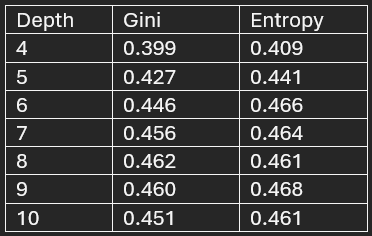

As you can see, the best model is usually the entropy decision tree in this scenario, only losing to gini once.

Additionally, below are the tables of the weighted averages of precision and recall at every depth for both. Weighted average was picked over regular average since it felt it covered the data more accurately

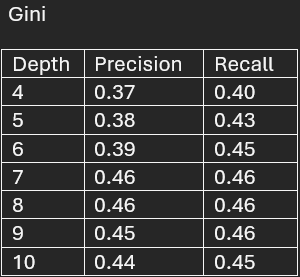

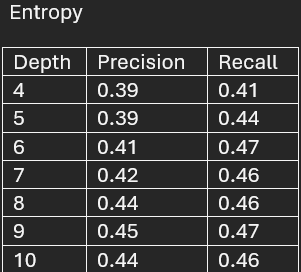


The table below is for the Random forest model, giving detailed data on number of estimators, accuracy, precision, recall and time taken to calculate, all in percentages except time

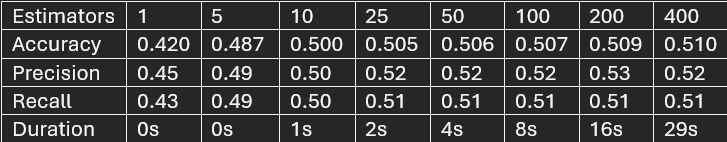

It can be said that the time taken to train increases exponentially in relation to the estimators whereas accuracy scales logorithmically

# 6. Visual Evidence and Error Analysis

# Visual Evidence

Below is the congregation of all gathered data into neat little graphs. First 2 relate to the simple decision tree while the latter 2 refer to the random forest

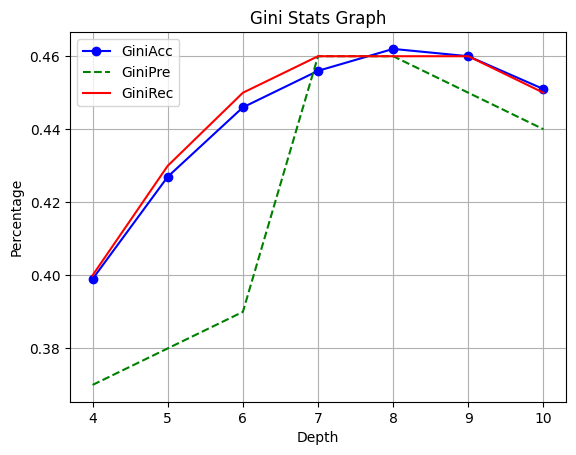

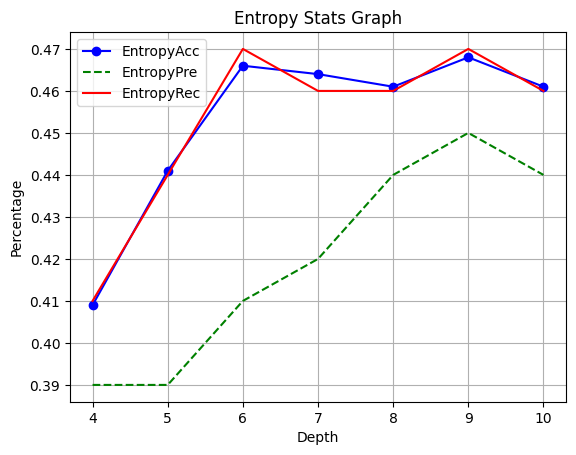

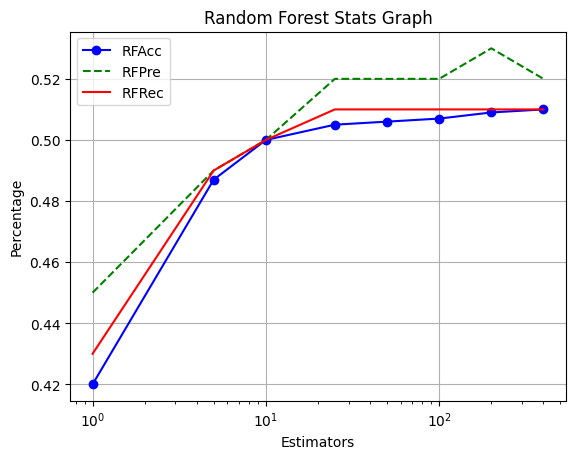

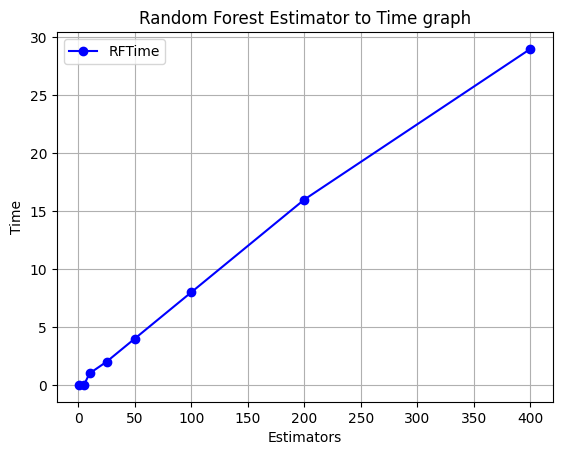

In [ ]:
# @title
import matplotlib.pyplot as plt

# 1. Define your data
Depth = [4,5,6,7,8,9,10]
GiniAcc = [0.399, 0.427, 0.446, 0.456, 0.462,0.460, 0.451]
GiniPre = [0.37 ,0.38 ,0.39 ,0.46 ,0.46 ,0.45 ,0.44 ]
GiniRec = [0.40 ,0.43 ,0.45 ,0.46 ,0.46 ,0.46 ,0.45 ]
EntropyAcc = [0.409 ,0.441 ,0.466 ,0.464 ,0.461 ,0.468 ,0.461 ]
EntropyPre = [0.39 ,0.39 ,0.41 ,0.42 ,0.44 ,0.45 ,0.44 ]
EntropyRec = [0.41 ,0.44 ,0.47 ,0.46 ,0.46 ,0.47,0.46 ]

#Gini Plotting
plt.plot(Depth, GiniAcc, label='GiniAcc', color='blue', marker='o')
plt.plot(Depth, GiniPre, label='GiniPre', color='green', linestyle='--')
plt.plot(Depth, GiniRec, label='GiniRec', color='red')
plt.title("Gini Stats Graph")
plt.xlabel("Depth")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)
plt.show()

plt.clf()

#Entropy Plotting
plt.plot(Depth, EntropyAcc, label='EntropyAcc', color='blue', marker='o')
plt.plot(Depth, EntropyPre, label='EntropyPre', color='green', linestyle='--')
plt.plot(Depth, EntropyRec, label='EntropyRec', color='red')
plt.title("Entropy Stats Graph")
plt.xlabel("Depth")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)
plt.show()

plt.clf()

#Random Forest Plotting, x axis is logarithmic to reflect estimator growth
Estimators = [1,5,10,25,50,100,200,400]
RFAcc = [0.420 ,0.487 ,0.500 ,0.505 ,0.506 ,0.507 ,0.509 ,0.510 ]
RFPre = [0.45 ,0.49 ,0.50 ,0.52 ,0.52 ,0.52 ,0.53 ,0.52 ]
RFRec = [0.43 ,0.49 ,0.50 ,0.51 ,0.51 ,0.51 ,0.51 ,0.51 ]
RFTime = [0 ,0 ,1 ,2 ,4 ,8 ,16 ,29 ]

plt.plot(Estimators, RFAcc, label='RFAcc', color='blue', marker='o')
plt.plot(Estimators, RFPre, label='RFPre', color='green', linestyle='--')
plt.plot(Estimators, RFRec, label='RFRec', color='red')
plt.title("Random Forest Stats Graph")
plt.xlabel("Estimators")
plt.ylabel("Percentage")
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()

plt.clf()

plt.plot(Estimators, RFTime, label='RFTime', color='blue', marker='o')
plt.title("Random Forest Estimator to Time graph")
plt.xlabel("Estimators")
plt.ylabel("Time")
plt.legend()
plt.grid(True)
plt.show()


# Error Analysis

There is quite a few potential errors in this experiment.


*   Inaccurate timing for random forest calculations which could've intefered with collected data
*   Humans designed the dataset given, which means that some of the values given may be inaccurate and up for reevaluation. This may include things like instrumentalness or speechiness. Even whole classes may be interpretted differently depending on who listens to them.

* Songs may have more than one genre or be a combination of genres, which again, may significantly impact collected data
* Gathered data pool is relatively small, so some trends may not be accurate

The model plays favorites, as it was not discussed earlier due to lack of relevancy, it does have a very high chance of finding specific genres and a very low chance at other. This can be seen in the classification report for all trees. It specifically finds class 7 very well while missing class 1 very often



# 7. Interpretation and Comparison

Before diving into this, it should be noted that weighted average was used in previous measurements and interpretation of data. This was done since it is thought that it covers the data better and more accurately than a regular average.





# Simple Decision Tree

Firstly, the evaluation of the basic decision tree with entropy and gini.

Entropy was the clear favorite of the 2, as it was more accurate almost all the time, aside from 1 depth change.

There was also the relatively inconsistent pattern of decreasing accuracy as depth increased past 8, but increased as it went up to 8, suggesting overfitting at higher depths.

Looking strictly at the weighted precision and recall of the both, entropy was again, the clear favorite. Entropy matched or exceeded gini in all recall averages, having a slight dip at depths 7 and 8. The recall started to fall after depths of 9, again suggesting overfitting. Entropy's precision steadily rose before depth 10, then began to decline. With these 2 findings, it can be said that the depth of 9 is optimal for this specific problem, as any more would overfit and any less would be less accurate, have less precision, and possibly lower recall.

Now looking at the gini of the first tree, it has a strange pattern in most aspects. It's accuracy rose very quickly until the depth of 8, where it then began falling. It's precision and recall followed a very similar pattern, shooting up then trickling down after depth 8. With the collection of findings, building with a gini criterion would yield it's best results at depth 8, where it reaches it's peak in every catagory of accuracy. Any lower or higher would mean less of every statistic of measurement.

To summarize, gini rose to it's maximum at depth of 8 while entropy rose at 9. Both started to decline after their maximum which suggests overfitting. Entropy almost always beat out gini except for at depth 8 and always had higher or equal recall. It is decided that Entropy was the better criterion for this model.

# Random Forest

Random forest was an interesting one, as it was thought to include the measurement of time since it was taking noticeably longer every time estimators were increased.

Starting off simple, the accuracy always increased as more estimators were involved, whichs is to be expected as it means more voting, which means less bias and less overfitting if any of them did so.

The precision and recall all generally increased, albeit at a snails pace. it should be noted that at 400 estimators, the precision did actually reduce, which suggests that more false positives were happening with more estimators.

The most interesting statistic in my opinion was of the time taken when estimators increased. The data suggests that the number of estimators determined how long the data took to load, having a seemingly linear relationship. Every 100 estimators brought about 8 seconds of computation in this experiment.

Putting all of this information together, more estimators seems to provide more accuracy at the expense of increased training time. There is a hint of deviation from this pattern with higher estimators, as precision lowered after 200 estimators, so it is advised that while the model does get more accurate with more estimators, take it with a grain of salt.

# Final notes

Random forest is a relatively vast improvement to the simple entropy decision tree, being better in literally every single aspect aside from when it only had 1 estimator (essentially making it a simple decision tree). Evidence to support this is, again, every single measured statistic being higer.

Increasing estimators slowly but surely increased all stats, but there was a hint of decline at the end of the experiment. Additionally, the increase in estimators caused immense increase in computational time, being a linear growth pattern.

Increasing depth lead to a general increase in all stats before a slow decline in all stats, which suggests overfitting. The recorded best depth for our problem was about 8-9.

Our model, I believe, did fairly well in predicting the correct genre all things considered. The possibility of error is always going to be quite high for this particular problem given the immense amount of error potential, so a 50% chance of guessing the correct genre is good.

What the model didn't do well was the weird pattern of getting very high accuracy for certain genre and very low accuracy for others. The leading theory is that those songs in particular are a combination of others, have a very minute difference with the other genre, or that decision trees may not be the way for those genre.

# 8. Reflection

Well I was expecting higher accuracy from the project coming into this, but after looking at all the potential errors that may occur, 50% seems like a pretty good bar.

Decision trees are a pretty unique and simple to implement model, which I could honestly use in day to day life at this rate.

Random forest are probably inefficient when compared to more advanced models, given that they essentially generate hundreds, if not thousands of smaller models. Really makes you think just how much mechanical thinking is happening in data centers.

sklearn is still the goat

